In [ ]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights

from rise.rise import RISE
from rise.rise_banzhaf import RISE_B
import rise.utils as utils
from rise.utils import IMAGES

## Model

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained weights
weights = ResNet50_Weights.DEFAULT

# Build model
model = models.resnet50(weights=weights)
model = model.to(device)
model.eval()

# Preprocessing transform
preprocess = weights.transforms()

## Init RISE

In [5]:
img_path = IMAGES / "catdog.png"
img, img_x = utils.load_image(img_path, device, preprocess)

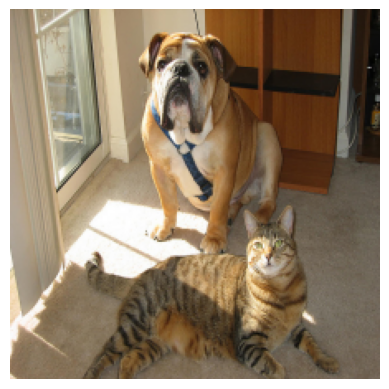

In [6]:
utils.draw_image(img)

In [7]:
rise = RISE(model, img_x)
rise.generate_masks(N=5000, s=7, p=0.1)

Generating filters: 100%|██████████| 5000/5000 [00:01<00:00, 3289.44it/s]


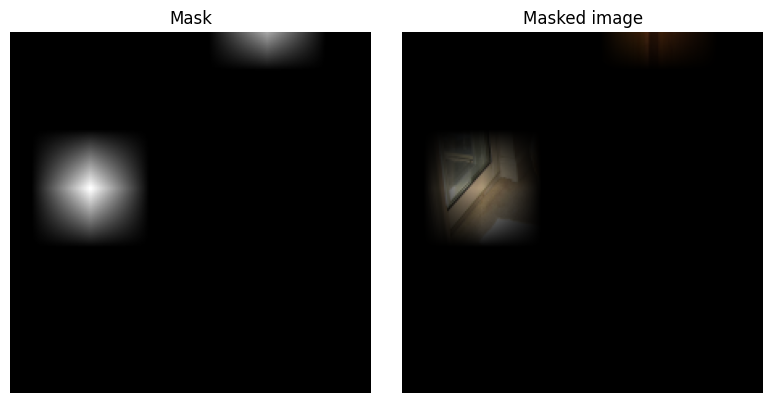

In [8]:
utils.draw_masked_image(img, rise.masks[42])

## RISE

In [9]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)
topk

[{'class_id': 243, 'class_name': 'bull mastiff', 'logit': 6.158624649047852},
 {'class_id': 281, 'class_name': 'tabby', 'logit': 3.580155611038208},
 {'class_id': 242, 'class_name': 'boxer', 'logit': 3.4773542881011963},
 {'class_id': 180,
  'class_name': 'American Staffordshire terrier',
  'logit': 3.3361282348632812},
 {'class_id': 282, 'class_name': 'tiger cat', 'logit': 3.3233225345611572}]

In [10]:
sal = rise(img_x)

Running model: 100%|██████████| 50/50 [00:05<00:00,  8.61it/s]


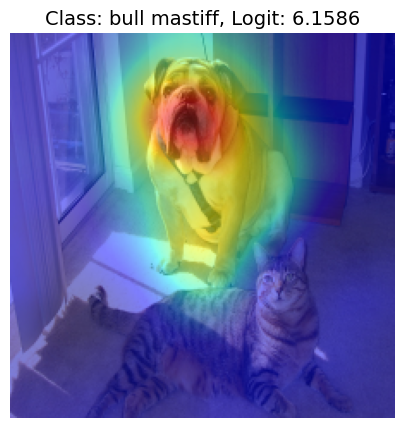

In [11]:
sal_map1 = utils.draw_saliency_overlay(img, sal, topk, k=0)

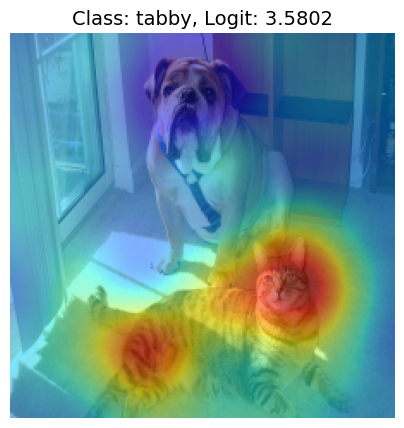

In [12]:
sal_map2 = utils.draw_saliency_overlay(img, sal, topk, k=1)


## Analysis of the RISE implementation


### Mask Geneeration

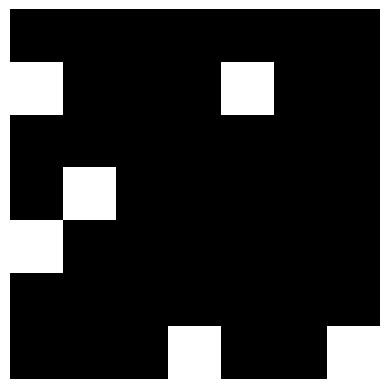

In [13]:
input_size = (img_x.shape[2], img_x.shape[3])
cell_size = np.ceil(np.array(input_size) / 7).astype(int)

grids = np.random.rand(50, 7, 7) < 0.1
grids = grids.astype('float32')

utils.draw_mask(grids[1])

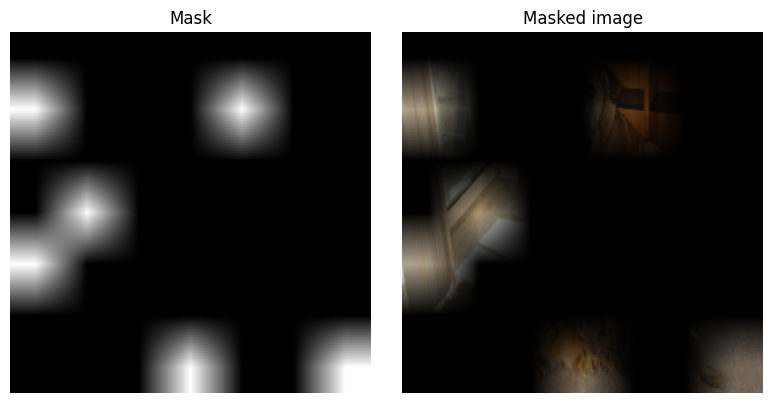

In [14]:
from rise.rise import resize_mask

up_size = 7 * cell_size   

up_mask = resize_mask(grids[1], up_size)
utils.draw_masked_image(img, up_mask.reshape(-1, input_size[0], input_size[1]))

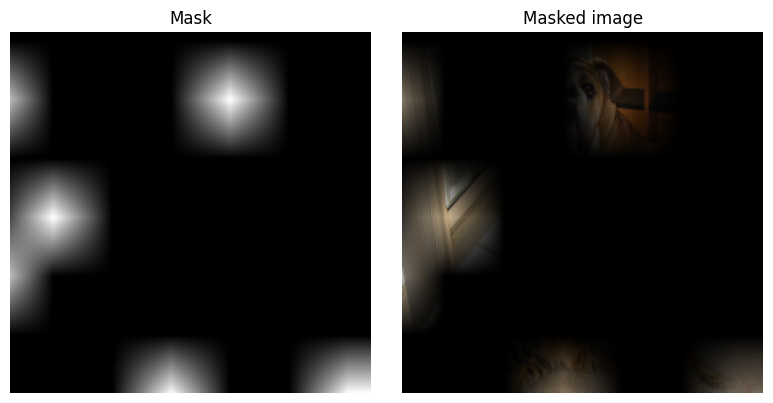

13 28


In [15]:
x = np.random.randint(0, cell_size[0])
y = np.random.randint(0, cell_size[1])

up_size = (7 + 1) * cell_size   # +1 so we can shift grids
up_mask = resize_mask(grids[1], up_size, mode='bilinear')
mask = up_mask[x:x + input_size[0],y:y + input_size[1]]
utils.draw_masked_image(img, mask.reshape(-1, input_size[0], input_size[1]))

print(x,y)

# RISE Banzhaf

In [16]:
rise_banzhaf = RISE_B(model, img_x)

In [18]:
rise_banzhaf.generate_masks(50, 7, 0.5)

In [19]:
sal = rise_banzhaf.forward(img_x)

Banzhaf sampling: 100%|██████████| 50/50 [00:05<00:00,  9.57it/s]

Total forward passes: 1284


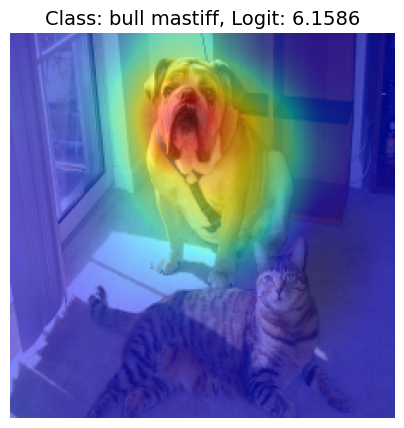

In [20]:
sal_map = utils.draw_saliency_overlay(img, sal, topk, k=0)

## Another Image

In [37]:
img_path = IMAGES / "prens.png"
img, img_x = utils.load_image(img_path, device, preprocess)

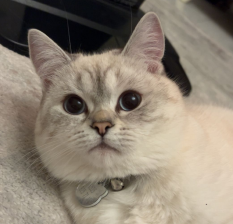

In [38]:
img

In [39]:
rise = RISE(model, img_x)
rise.generate_masks(N=4000, s=7, p=0.1)

Generating filters: 100%|██████████| 4000/4000 [00:01<00:00, 2752.72it/s]


In [40]:
sal = rise.forward(img_x)

Running model: 100%|██████████| 40/40 [00:05<00:00,  7.94it/s]


In [41]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)

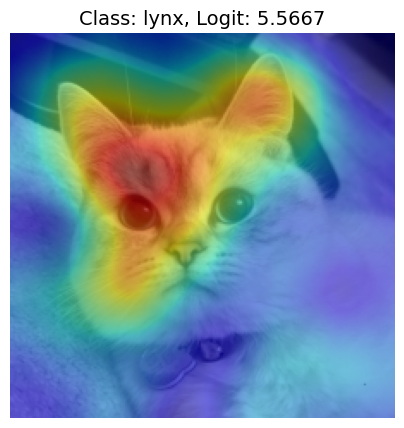

In [42]:
sal_map_prens = utils.draw_saliency_overlay(img, sal, topk=topk, k=0)

In [44]:
rise_banzhaf = RISE_B(model, img_x)
rise_banzhaf.generate_masks(50, 7, 0.5)
sal_banzhaf = rise_banzhaf.forward(img_x)

Banzhaf sampling: 100%|██████████| 50/50 [00:05<00:00,  9.96it/s]

Total forward passes: 1267


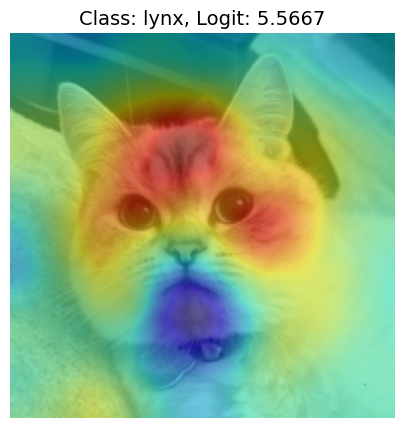

In [48]:
sal_map_banzhaf = utils.draw_saliency_overlay(img, sal_banzhaf, topk, k=0)